<a href="https://colab.research.google.com/github/KishoreKumar477/ml-supervised/blob/main/malignantvsbenign_cancerprediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,f1_score

#Loading the Breast Cancer Wisconsin (Diagnostic) Dataset


In [38]:
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target)


In [39]:
print(f"Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features.")
print("Target names: ", list(cancer.target_names))

Dataset loaded: 569 samples, 30 features.
Target names:  [np.str_('malignant'), np.str_('benign')]


# Exploratory Data Analysis (EDA)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38           122.8     1001.0           0.1184   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0            0.2776          0.3001               0.1471         0.2419   

   mean fractal dimension  radius error  texture error  perimeter error  \
0                 0.07871         1.095         0.9053            8.589   

   area error  smoothness error  compactness error  concavity error  \
0       153.4          0.006399            0.04904          0.05373   

   concave points error  symmetry error  fractal dimension error  \
0               0.01587         0.03003                 0.006193   

   worst radius  worst texture  worst perimeter  worst area  worst smoothness  \
0         25.38          17.33            184.6      2019.0            0.1622   

   worst compactness  worst concavity  worst concave points  worst symmetry  \
0             0.6656   

/tmp/ipykernel_15246/2883814108.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


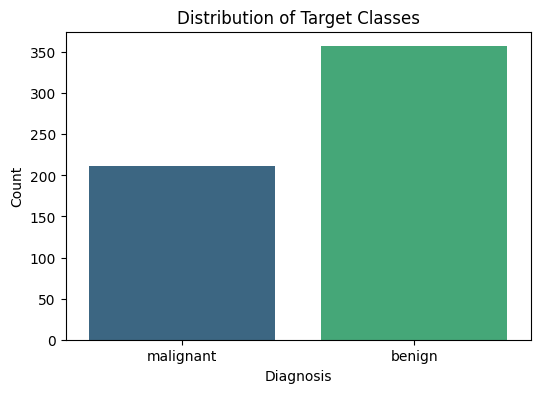

In [40]:
pd.set_option('display.max_columns', None)
print(X.head(1))

print(X.describe())

print(X.isnull().sum()[X.isnull().sum() > 0])

plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='viridis')
plt.title('Distribution of Target Classes')
plt.xticks(ticks=[0, 1], labels=cancer.target_names)
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

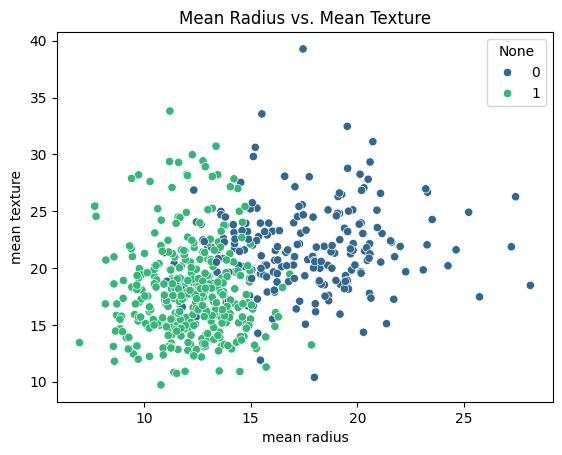

In [41]:
sns.scatterplot(x=X['mean radius'], y=X['mean texture'], hue=y, palette='viridis')
plt.title('Mean Radius vs. Mean Texture')
plt.show()

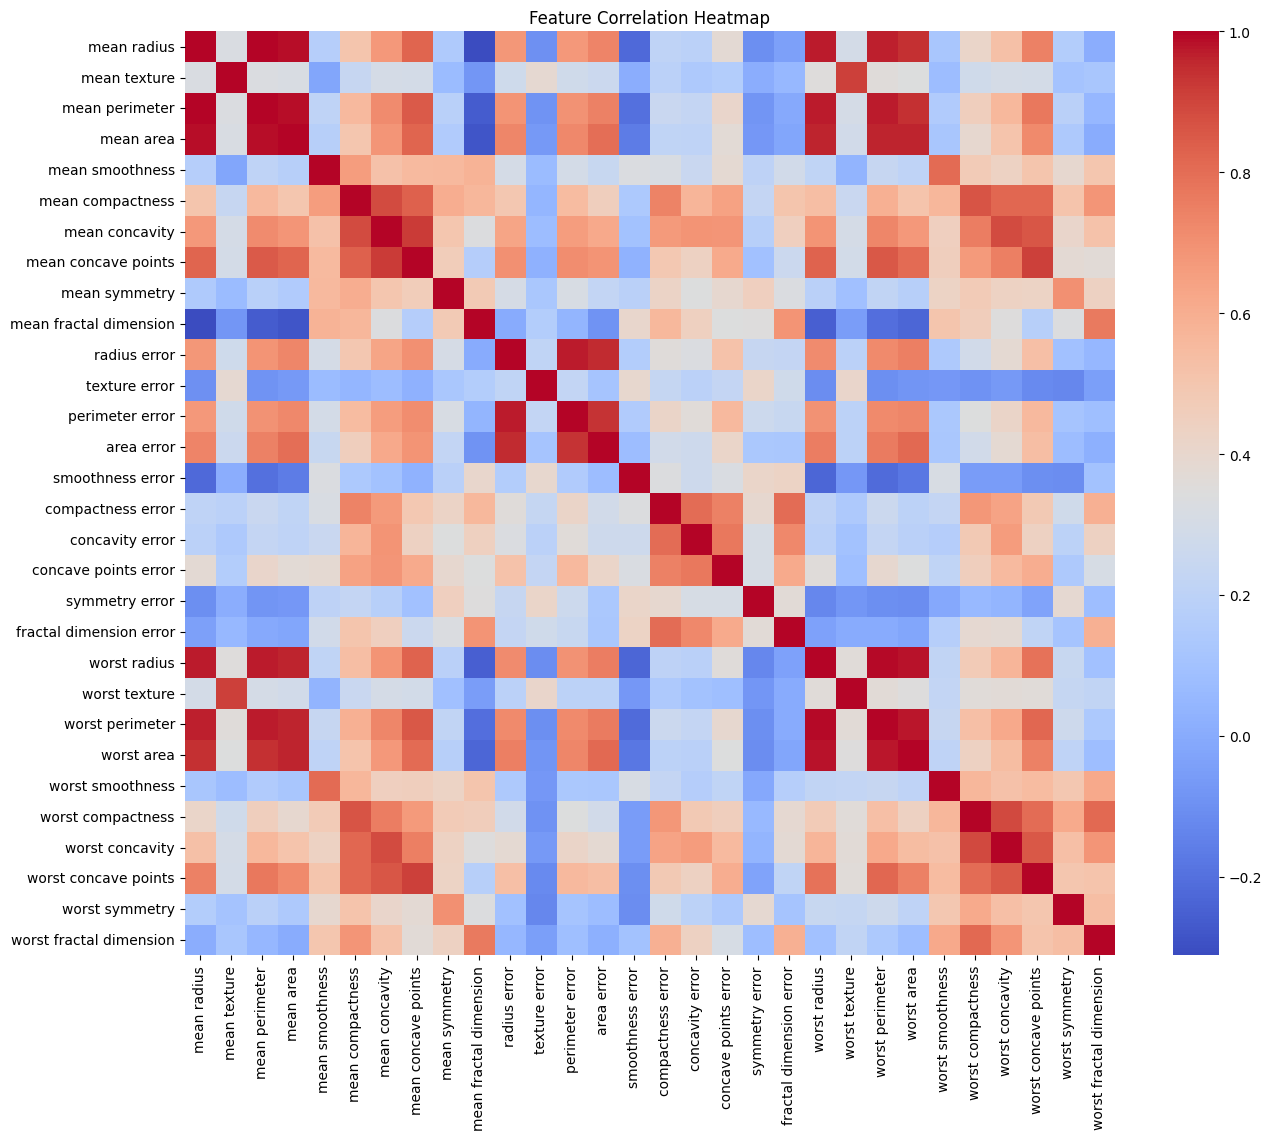

In [42]:
plt.figure(figsize=(15, 12))
sns.heatmap(X.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

#Data Preprocessing

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train set: {X_train.shape[0]} samples, Test set: {X_test.shape[0]} samples")


Train set: 455 samples, Test set: 114 samples


In [44]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


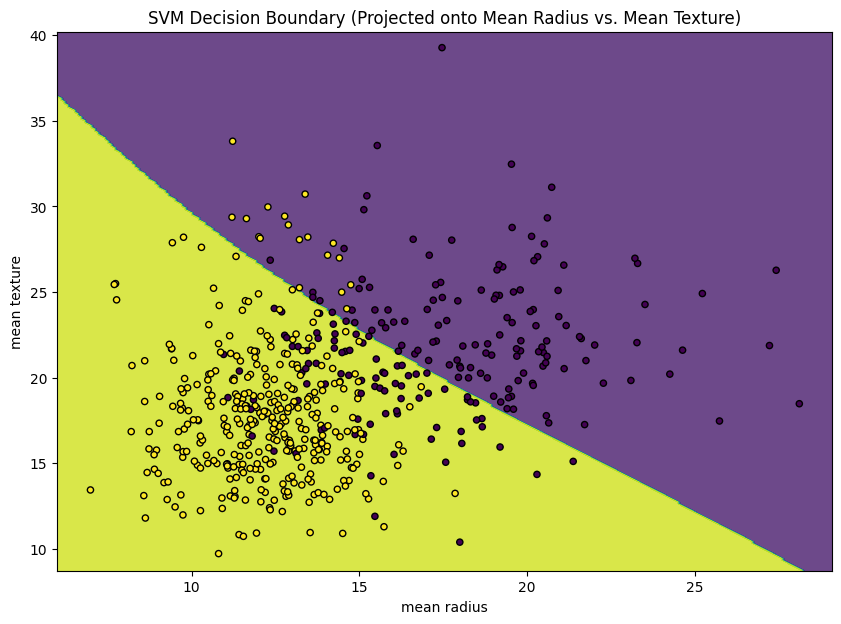

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Define the features for the 2D decision boundary plot
feature1_name = 'mean radius'
feature2_name = 'mean texture'

# Get the min and max values for the selected features from the original data
min1, max1 = X[feature1_name].min() - 1, X[feature1_name].max() + 1
min2, max2 = X[feature2_name].min() - 1, X[feature2_name].max() + 1

# Create a meshgrid for the two features
x1_grid, x2_grid = np.meshgrid(np.arange(min1, max1, 0.1),
                                 np.arange(min2, max2, 0.1))

# Create a DataFrame for prediction, filling other features with their mean values from X_train
# This is crucial because our svm_model was trained on all 30 features.
# We need to replicate the structure of X_train for prediction.

# Calculate mean of X_train for other features
X_train_mean = X_train.mean()

# Prepare the input for prediction, ensuring all 30 features are present
# Start with a base DataFrame where all features are at their training mean
X_pred_base = pd.DataFrame(np.tile(X_train_mean.values, (x1_grid.size, 1)), columns=X.columns)

# Fill the two selected features with the meshgrid values
X_pred_base[feature1_name] = x1_grid.ravel()
X_pred_base[feature2_name] = x2_grid.ravel()

# Scale the prediction DataFrame using the original scaler
X_pred_scaled = scaler.transform(X_pred_base)

# Predict classes for each point in the meshgrid
Z = svm_model.predict(X_pred_scaled)

# Reshape the predictions to match the meshgrid shape
Z = Z.reshape(x1_grid.shape)

# Plot the decision boundary
plt.figure(figsize=(10, 7))
plt.contourf(x1_grid, x2_grid, Z, alpha=0.8, cmap=plt.cm.viridis)
plt.scatter(X[feature1_name], X[feature2_name], c=y, s=20, edgecolors='k', cmap=plt.cm.viridis)
plt.xlabel(feature1_name)
plt.ylabel(feature2_name)
plt.title('SVM Decision Boundary (Projected onto Mean Radius vs. Mean Texture)')
plt.show()

In [46]:
# Convert back to DataFrame for consistency (optional, but good for inspection)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

#Support Vector Machine (SVM) Classifier Training


In [47]:
svm_model = SVC(kernel='rbf',random_state=42) # 'linear', 'rbf', 'poly', 'sigmoid'
svm_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

# Model Evaluation on Test Set


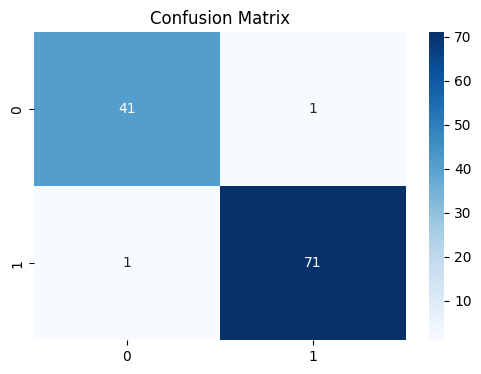

Test Set Accuracy: 0.9825
Test Set F1 Score: 0.9861

Confusion Matrix:
 [[41  1]
 [ 1 71]]

Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [48]:
y_pred = svm_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, cmap=plt.cm.Blues,annot=True)
plt.title('Confusion Matrix')
plt.show()
class_report = classification_report(y_test, y_pred, target_names=cancer.target_names)

print(f"Test Set Accuracy: {accuracy:.4f}")
print(f"Test Set F1 Score: {f1:.4f}")
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

#Cross-Validation (KFold,StratifiedKFold)

In [49]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5-fold cross-validation
cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=skf, scoring='accuracy')

print(f"Cross-validation scores (5-fold): {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

print("\nCancer prediction process completed with SVM, EDA, and cross-validation.")

Cross-validation scores (5-fold): [0.94505495 0.97802198 0.95604396 0.96703297 0.98901099]
Mean CV Accuracy: 0.9670 (+/- 0.0155)

Cancer prediction process completed with SVM, EDA, and cross-validation.


In [50]:
kf = KFold(n_splits=5, shuffle=True, random_state=42) # 5-fold cross-validation
cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=kf, scoring='accuracy')

print(f"Cross-validation scores (5-fold): {cv_scores}")
print(f"Mean CV Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

print("\nCancer prediction process completed with SVM, EDA, and cross-validation.")

Cross-validation scores (5-fold): [1.         0.97802198 0.98901099 0.97802198 0.92307692]
Mean CV Accuracy: 0.9736 (+/- 0.0266)

Cancer prediction process completed with SVM, EDA, and cross-validation.
